In [1]:
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt

from utils.score_responses import ResponseEvaluator
from utils.parsing import parse_fen
from utils.board import get_piece_name_at_location

In [2]:
# CONFIG
# PARENT_DIR = Path("model_outputs")
# DATA_FOLDERS = [
#     'eval-qwen25-7b-sftdm6-drgrpo-dm6-400',
#     'l4mav-rejsampling-predictmove-no_cutoff',
#     'llmchess-kimi-k2-rejsampling-1000',
#     'rejsampling-llama4-maverick-7_11_25',
#     'llmchess-qwen25-7b-400'
# ]
PARENT_DIR = Path("processed_data")
DATA_FOLDERS = [
    None,
]

In [3]:
# Populate our board result dicts
board_result_dicts = {}
for data_folder in DATA_FOLDERS:
    folder_path = Path(PARENT_DIR) if data_folder is None else Path(PARENT_DIR) / data_folder
    for json_file in folder_path.glob("*.json*"):
        if json_file.suffix not in {".json", ".jsonl"}:
            continue
        key = f"{json_file.name} - [{data_folder}]"
        evaluator = ResponseEvaluator(str(folder_path), json_file.name)
        board_result_dicts[key] = evaluator.board_id_results

--------------------------------------------------
Results for bestmove_rejsampling_l4mav_originalcutoff_balanced_1680.jsonl:
Filename: bestmove_rejsampling_l4mav_originalcutoff_balanced_1680.jsonl
Count: Sample Questions: 1435
Count: Total Generations: 1680
Count: Legal Generations: 1680
Total: Cumulative Score: 1680
Error: Illegal Move: 0
Error: Parsing: 0
Error: Other: 0
Avg. Score - All: 1.0
Avg. Score - Legal: 1.0
Error Rate: 0.0
--------------------------------------------------

--------------------------------------------------
Results for predictmove_rejsampling_l4mav_originalcutoff_balanced_2650.jsonl:
Filename: predictmove_rejsampling_l4mav_originalcutoff_balanced_2650.jsonl
Count: Sample Questions: 2321
Count: Total Generations: 2650
Count: Legal Generations: 2650
Total: Cumulative Score: 2279.651204571636
Error: Illegal Move: 0
Error: Parsing: 0
Error: Other: 0
Avg. Score - All: 0.8602457375742022
Avg. Score - Legal: 0.8602457375742022
Error Rate: 0.0
---------------------

In [4]:
def bar_by(df, x_col, y_col, *, n_bins=10, title=None):
    """
    Dual‑axis bar plot:
      • left  y‑axis: mean(y_col) per bucket (blue)
      • right y‑axis: count per bucket (orange)

    Buckets: unique values if ≤10 else `n_bins` equal‑width numeric buckets.
    """
    x, y = df[x_col], df[y_col]

    # ── Bucket assignment ────────────────────────────────────────────
    if pd.api.types.is_numeric_dtype(x):
        if x.nunique() <= 10:
            labels = sorted(x.unique())
            grp_idx = x
        else:
            bins   = np.linspace(x.min(), x.max(), n_bins + 1)
            labels = [f"{int(bins[i])}–{int(bins[i+1]-1)}" for i in range(n_bins)]
            grp_idx = pd.cut(x, bins=bins, labels=labels, include_lowest=True)
    else:  # categorical x
        labels  = sorted(x.astype(str).unique())
        grp_idx = x.astype(str)

    # ── Aggregation ──────────────────────────────────────────────────
    mean_vals  = y.groupby(grp_idx, observed=True).mean().reindex(labels)
    count_vals = y.groupby(grp_idx, observed=True).count().reindex(labels).fillna(0)

    # ── Plot ─────────────────────────────────────────────────────────
    xpos, width = np.arange(len(labels)), 0.35
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    bars_mean  = ax1.bar(xpos - width/2, mean_vals.values, width, color="#1f77b4")
    bars_count = ax2.bar(xpos + width/2, count_vals.values, width,
                         color="orange", label="# samples")

    ax1.set_xlabel(x_col)
    ax1.set_ylabel(f"mean({y_col})")
    ax2.set_ylabel("count")
    ax1.set_xticks(xpos)
    ax1.set_xticklabels(labels, rotation=45, ha="right")
    ax1.set_title(title or f"{y_col} by {x_col}")

    # Annotate bars
    for rect in bars_mean:
        ax1.text(rect.get_x() + rect.get_width()/2,
                 rect.get_height() + 0.01,
                 f"{rect.get_height():.2f}",
                 ha="center", va="bottom", fontsize=8)
    for rect in bars_count:
        ax2.text(rect.get_x() + rect.get_width()/2,
                 rect.get_height() + 0.01,
                 f"{int(rect.get_height())}",
                 ha="center", va="bottom", fontsize=8)

    ax1.legend([bars_count], ["# samples"], loc="upper right")
    fig.tight_layout()
    plt.show()

# Predict Move   
---

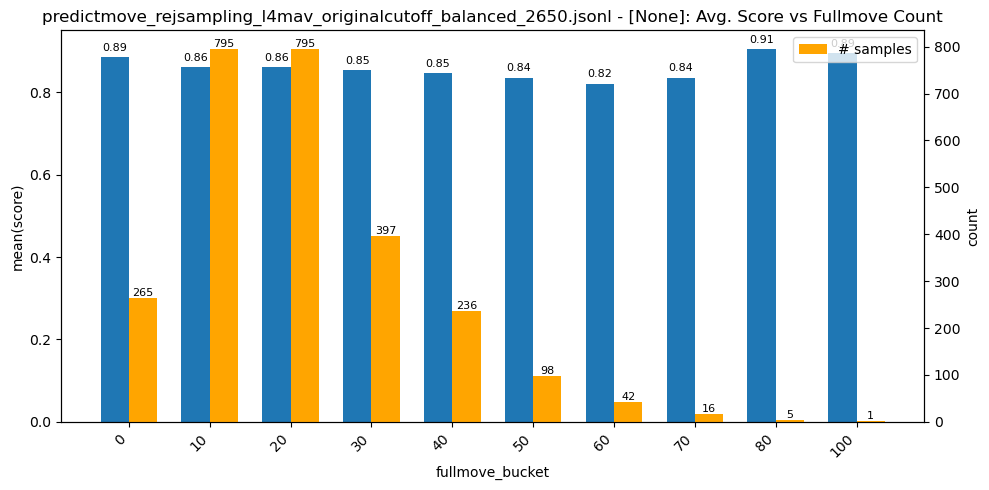


predictmove_rejsampling_l4mav_originalcutoff_balanced_2650.jsonl - [None] — Top 20 moves:
e1g1     count=164   mean=0.866 std=0.084
e8g8     count=119   mean=0.898 std=0.076
b1c3     count=77    mean=0.867 std=0.081
b8c6     count=73    mean=0.874 std=0.078
g8f6     count=53    mean=0.891 std=0.074
d7d5     count=51    mean=0.881 std=0.088
g1f3     count=47    mean=0.912 std=0.059
d1e2     count=41    mean=0.836 std=0.075
a1d1     count=40    mean=0.848 std=0.075
c7c5     count=34    mean=0.822 std=0.076
f1e1     count=32    mean=0.874 std=0.077
f7f5     count=28    mean=0.860 std=0.084
d2d4     count=27    mean=0.887 std=0.074
d2f3     count=23    mean=0.857 std=0.081
f1d1     count=22    mean=0.834 std=0.078
e1e7     count=20    mean=0.893 std=0.091
d1d3     count=20    mean=0.832 std=0.091
e7d7     count=19    mean=0.820 std=0.060
d8d5     count=18    mean=0.866 std=0.057
d1c2     count=18    mean=0.818 std=0.067
------------------------------------------------------------


In [5]:
for key, results in board_result_dicts.items():
    if not key.startswith("predictmove"):
        continue

    rows = []
    for board_id, data in results.items():
        fullmove = parse_fen(data['info']["board"])["fullmove_number"]
        for score_raw, move in data.get("score_answers", []):
            try:         # numeric score or NaN for '<ERROR>'
                score = float(score_raw)
            except (ValueError, TypeError):
                score = np.nan
            rows.append({
                "board_id": board_id,
                "fullmove": fullmove,
                "move":     move,
                "score":    score,
            })

    if not rows:
        continue

    df = pd.DataFrame(rows)

    # ── 1) Histogram (mean score vs fullmove buckets) ────────────
    clean_df = df.dropna(subset=["score"])
    if not clean_df.empty:
        df["fullmove_bucket"] = (df["fullmove"] // 10) * 10
        bar_by(
            df.dropna(subset=["score"]),
            x_col="fullmove_bucket",
            y_col="score",
            title=f"{key}: Avg. Score vs Fullmove Count"
        )

    # ── 2) Move statistics ───────────────────────────────────────
    print(f"\n{key} — Top 20 moves:")
    move_counts = df["move"].value_counts().head(20)
    move_stats  = (
        df.groupby("move")["score"]
            .agg(["mean", "std"])
            .reindex(move_counts.index)
    )
    for mv in move_counts.index:
        cnt  = move_counts[mv]
        mean = move_stats.loc[mv, "mean"]
        std  = move_stats.loc[mv, "std"]
        mean_str = f"{mean:.3f}" if not np.isnan(mean) else "—"
        std_str  = f"{std:.3f}"  if not np.isnan(std)  else "—"
        print(f"{mv:<8} count={cnt:<5} mean={mean_str} std={std_str}")
    print("-" * 60)

# Legal Moves   
---

In [6]:
for key, results in board_result_dicts.items():
    if not key.startswith("legalmoves"):
        continue

    rows = []
    for board_id, data in results.items():
        piece = data["info"]["task_data"][0]   # e.g. 'black bishop'
        for score_raw, _ in data.get("score_answers", []):
            try:
                score = float(score_raw)      # 0‥1 numeric
            except (ValueError, TypeError):
                score = pd.NA                 # '<ERROR>' → NA
            rows.append({"piece": piece, "score": score})

    df = pd.DataFrame(rows).dropna(subset=["score"]).astype({"score": float})
    if df.empty:
        print(f"{key}: no valid scores")
        continue

    bar_by(
        df,
        x_col="piece",
        y_col="score",
        title=f"{key}: mean score by piece (count overlay)"
    )

# Best Move   
---

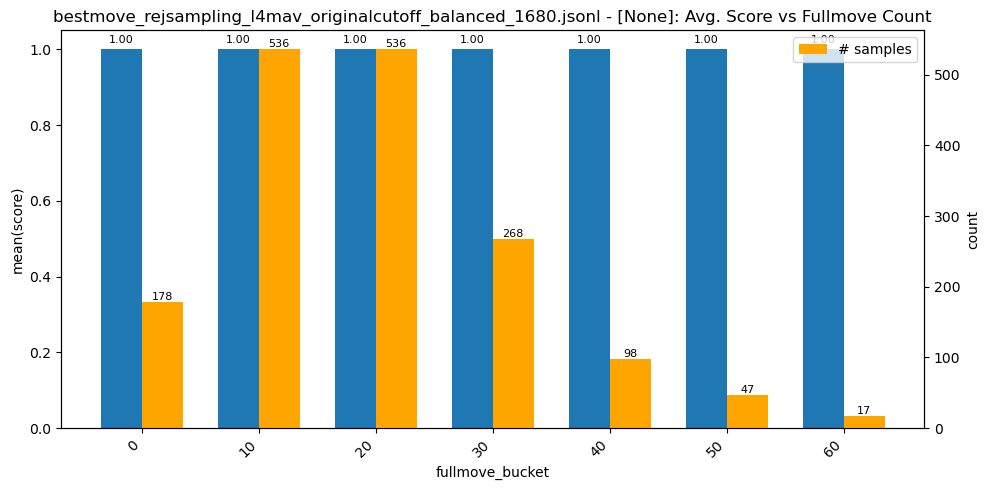

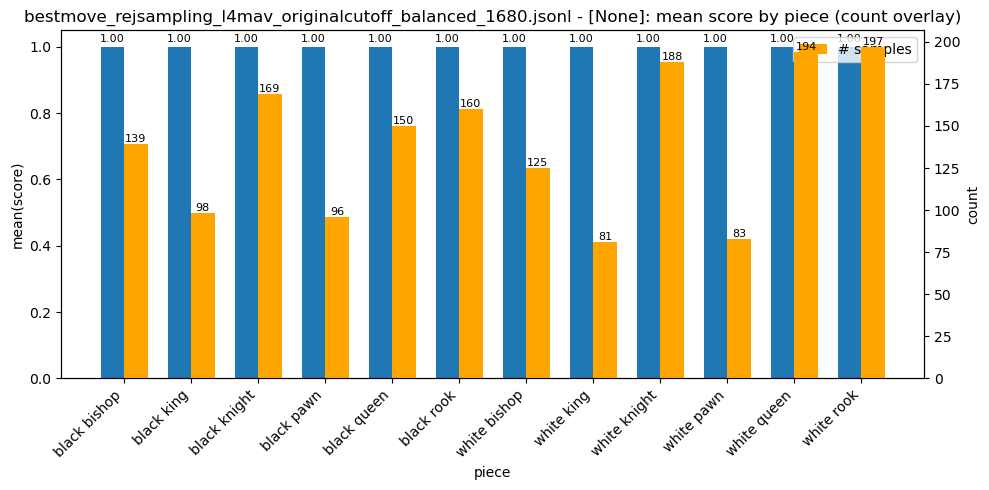

In [7]:
for key, results in board_result_dicts.items():
    if not key.startswith("bestmove"):
        continue

    rows = []
    for board_id, data in results.items():
        fen       = data["info"]["board"]
        fullmove  = parse_fen(fen)["fullmove_number"]
        # correct answer square = first 2 chars of SAN‑less move string
        src_sq    = data["info"]["answer"]["answer"][:2].lower()

        piece = get_piece_name_at_location(fen, src_sq)  # e.g. 'white knight'

        for score_raw, _ in data.get("score_answers", []):
            try:
                score = float(score_raw)
            except (ValueError, TypeError):
                score = np.nan
            rows.append({
                "board_id": board_id,
                "fullmove": fullmove,
                "piece":    piece,
                "score":    score,
            })

    df = pd.DataFrame(rows).dropna(subset=["score"]).astype({"score": float})
    if df.empty:
        print(f"{key}: no valid scores.")
        continue

    # ─── 1) Score vs full‑move count buckets ────────────────────
    df["fullmove_bucket"] = (df["fullmove"] // 10) * 10
    bar_by(
        df.dropna(subset=["score"]),
        x_col="fullmove_bucket",
        y_col="score",
        title=f"{key}: Avg. Score vs Fullmove Count"
    )

    # ─── 2) Score vs piece type ─────────────────────────────────
    bar_by(
        df,
        x_col="piece",
        y_col="score",
        title=f"{key}: mean score by piece (count overlay)"
    )

# Worst Move   
---

In [8]:
for key, results in board_result_dicts.items():
    if not key.startswith("worstmove"):
        continue

    rows = []
    for board_id, data in results.items():
        fen       = data["info"]["board"]
        fullmove  = parse_fen(fen)["fullmove_number"]
        # correct answer square = first 2 chars of SAN‑less move string
        src_sq    = data["info"]["answer"]["answer"][:2].lower()

        piece = get_piece_name_at_location(fen, src_sq)  # e.g. 'white knight'

        for score_raw, _ in data.get("score_answers", []):
            try:
                score = float(score_raw)
            except (ValueError, TypeError):
                score = np.nan
            rows.append({
                "board_id": board_id,
                "fullmove": fullmove,
                "piece":    piece,
                "score":    score,
            })

    df = pd.DataFrame(rows).dropna(subset=["score"]).astype({"score": float})
    if df.empty:
        print(f"{key}: no valid scores.")
        continue

    # ─── 1) Score vs full‑move count buckets ────────────────────
    df["fullmove_bucket"] = (df["fullmove"] // 10) * 10
    bar_by(
        df.dropna(subset=["score"]),
        x_col="fullmove_bucket",
        y_col="score",
        title=f"{key}: Avg. Score vs Fullmove Count"
    )

    # ─── 2) Score vs piece type ─────────────────────────────────
    bar_by(
        df,
        x_col="piece",
        y_col="score",
        title=f"{key}: mean score by piece (count overlay)"
    )